In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

# load the artist-year profiles we built in artist_profile.ipynb
notebook_dir = os.path.abspath('')
processed_dir = os.path.normpath(os.path.join(notebook_dir, '..', '..', 'data', 'processed'))
df = pd.read_csv(os.path.join(processed_dir, 'artist_year_profiles.csv'))

print('Rows loaded:', len(df))
print('Columns:', df.columns.tolist())

Rows loaded: 3474
Columns: ['track_artist', 'release_year', 'mean_popularity', 'track_count', 'mean_danceability', 'mean_energy', 'mean_valence', 'mean_tempo', 'mean_acousticness', 'mean_speechiness', 'yearly_change', 'variability', 'career_age', 'next_popularity', 'declined']


## Goal
Instead of just asking "will this artist decline?" we want to understand why artists decline by first discovering what types of career patterns exist.
We use clustering to group artists into archetypes based on how their
careers have evolved over time. For example some artists peak early and
fade, others grow steadily, others stay consistently relevant.
Once we find these archetypes we can check whether different career patterns have different decline rates

In [13]:
# BUILD ARTIST LEVEL SUMMARY

# compute summary statistics across all years for each artist
artist_summary = df.groupby('track_artist').agg(
    career_length= ('release_year', 'nunique'),
    mean_popularity= ('mean_popularity', 'mean'),
    peak_popularity= ('mean_popularity', 'max'),
    min_popularity= ('mean_popularity', 'min'),
    mean_yearly_change= ('yearly_change', 'mean'),
    mean_variability= ('variability', 'mean'),
    mean_energy= ('mean_energy', 'mean'),
    mean_danceability= ('mean_danceability', 'mean'),
    mean_valence= ('mean_valence', 'mean'),
    decline_rate= ('declined', 'mean')
).reset_index()

print('Total Artist summaries created:', len(artist_summary))
artist_summary.head()

Total Artist summaries created: 1094


,track_artist,career_length,mean_popularity,peak_popularity,min_popularity,mean_yearly_change,mean_variability,mean_energy,mean_danceability,mean_valence,decline_rate
0,$uicideBoy$,3,59.337667,62.7273,57.0,-2.863650,3.072879,0.702200,0.790800,0.264767,0.000000
1,*NSYNC,2,62.500000,71.0000,54.0,17.000000,12.020815,0.928000,0.684000,0.857000,0.500000
2,11 Acorn Lane,3,35.000000,43.0000,22.0,9.000000,13.103530,0.905667,0.769000,0.788667,0.000000
3,112,3,52.166667,60.0000,46.0,-4.750000,8.523378,0.616167,0.717167,0.775900,0.333333
4,2 Chainz,4,55.000000,59.0000,49.0,3.333333,5.189464,0.655375,0.741875,0.414900,0.000000


In [14]:
# NORMALIZE FEATURES


# features to cluster on
features = ['career_length', 'mean_popularity', 'peak_popularity','min_popularity', 'mean_yearly_change', 'mean_variability',
    'mean_energy', 'mean_danceability', 'mean_valence'
]

# normalize 
scaler = StandardScaler()
X = scaler.fit_transform(artist_summary[features])

print('Feature matrix shape:', X.shape)


Feature matrix shape: (1094, 9)


k=2: silhouette score = 0.179
k=3: silhouette score = 0.182
k=4: silhouette score = 0.185
k=5: silhouette score = 0.159
k=6: silhouette score = 0.174
k=7: silhouette score = 0.169
k=8: silhouette score = 0.160


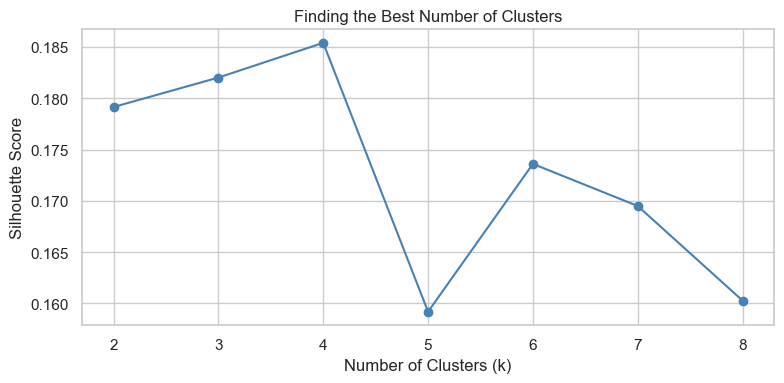


Best k: 4
Best silhouette score: 0.185


In [15]:
# FIND THE BEST NUMBER OF CLUSTERS

silhouette_scores = []
k_values = range(2, 9)

for k in k_values:
    # run kmeans with this number of clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    # calculate how well separated the clusters are
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f'k={k}: silhouette score = {score:.3f}')

# plot the scores so we can see which k is best visually
plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Finding the Best Number of Clusters')
plt.tight_layout()
plt.show()

# print the best k
best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print('\nBest k:', best_k)
print('Best silhouette score:', round(max(silhouette_scores), 3))

## Best Number of Clusters

We tested k=2 through k=8 and measured how well separatedmthe clusters were using silhouette score. Higher is better.

k=4 has the highest silhouette score and the chart shows a clear peak at 4 followed by a sharp drop at 5. This means 4 clusters gives the most distinct and well separated groups.

Note: scores in the 0.18 range mean artist careers exist on a continuum rather than falling into perfectly distinct groups. 

In [16]:
# RUN KMEANS WITH K=4

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
artist_summary['cluster'] = kmeans.fit_predict(X)

# see how many artists ended up in each cluster
print('Artists per cluster:')
print(artist_summary['cluster'].value_counts().sort_index())

Artists per cluster:
cluster
0    119
1    291
2    449
3    235
Name: count, dtype: int64


In [17]:
# INTERPRET EACH CLUSTER
cluster_profiles = artist_summary.groupby('cluster').agg(
    n_artists          = ('track_artist', 'count'),
    career_length      = ('career_length', 'mean'),
    mean_popularity    = ('mean_popularity', 'mean'),
    peak_popularity    = ('peak_popularity', 'mean'),
    mean_yearly_change = ('mean_yearly_change', 'mean'),
    mean_variability   = ('mean_variability', 'mean'),
    mean_energy        = ('mean_energy', 'mean'),
    mean_valence       = ('mean_valence', 'mean'),
    decline_rate       = ('decline_rate', 'mean')
).round(2)

print(cluster_profiles.to_string())

         n_artists  career_length  mean_popularity  peak_popularity  mean_yearly_change  mean_variability  mean_energy  mean_valence  decline_rate
cluster                                                                                                                                           
0              119           2.47            37.81            58.55               31.76             27.35         0.71          0.50          0.20
1              291           2.59            28.18            35.86               -1.73              8.45         0.74          0.50          0.21
2              449           2.77            56.51            63.11                0.23              7.21         0.68          0.51          0.25
3              235           5.03            41.66            63.84               -7.99             19.91         0.73          0.54          0.35


## Cluster Interpretation

Four clusters emerged but the differences between them are
modest. The silhouette score of 0.185 means there is
significant overlap between groups.

Cluster 0 — Fast Growth (119 artists)
The most noticiable feature is mean_yearly_change of +31.76 which is much higher than any other cluster. However career length is only 2.47 years meaning we have very little data on these artists. They may be rising stars or they may just be artist where we caught one good year. Hard to say with confidence.

Cluster 1 — Low Popularity Artists (291 artists)
The lowest popularity group (mean 28.18). Stable and consistent but never mainstream. Decline rate of 21% is similar to other clusters which suggests low popularity alone does not protect against decline.

Cluster 2 — Mainstream Artists (449 artists)
The largest group with the highest average popularity (56.51) and most stable careers (variability 7.21). Decline rate of 25% is moderate. This is essentially the "typical successfulartist" group in our dataset.

Cluster 3 — Long Career Declining Artists (235 artists)
The most distinct group. Longest careers (5.03 years), steepest downward trend (-7.99 per year), and highest decline rate (35%). The combination of long career and negative yearly change suggests these are established
artists losing momentum over time.

note: the decline rates across clusters (20% to 35%)
show some variation but are not dramatically different.

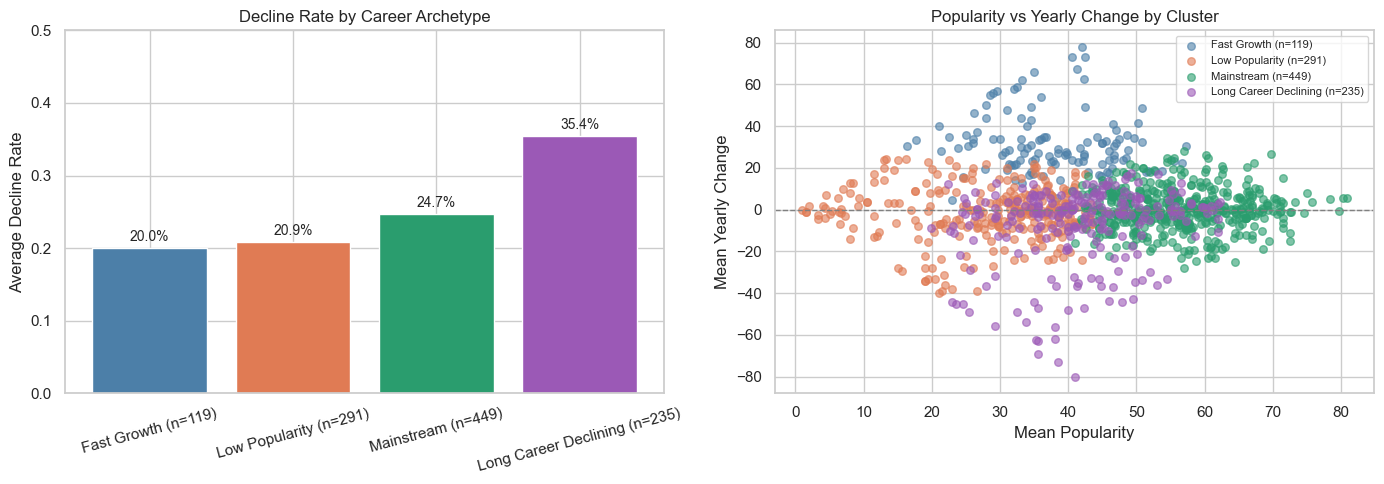

In [18]:
# VISUALIZE THE ARCHETYPES

# plot 1: bar chart comparing key metrics across clusters
# plot 2: scatter plot showing popularity vs yearly change colored by cluster

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# cluster labels for the legend
cluster_names = {
    0: 'Fast Growth (n=119)',
    1: 'Low Popularity (n=291)',
    2: 'Mainstream (n=449)',
    3: 'Long Career Declining (n=235)'
}
colors = ['#4c7fa8', '#e07b54', '#2a9d6e', '#9b59b6']

# PLOT 1 - decline rate per cluster

cluster_order = [0, 1, 2, 3]
decline_rates = [artist_summary[artist_summary['cluster'] == k]['decline_rate'].mean() for k in cluster_order]

axes[0].bar(
    [cluster_names[k] for k in cluster_order],
    decline_rates,
    color=colors
)
axes[0].set_ylabel('Average Decline Rate')
axes[0].set_title('Decline Rate by Career Archetype')
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_ylim(0, 0.5)

# add the percentage labels on top of each bar
for i, rate in enumerate(decline_rates):
    axes[0].text(i, rate + 0.01, f'{rate*100:.1f}%', 
                ha='center', fontsize=10)

# PLOT 2 - popularity vs yearly change colored by cluster

for k in cluster_order:
    subset = artist_summary[artist_summary['cluster'] == k]
    axes[1].scatter(
        subset['mean_popularity'],
        subset['mean_yearly_change'],
        label=cluster_names[k],
        color=colors[k],
        alpha=0.6,
        s=30
    )

axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Mean Popularity')
axes[1].set_ylabel('Mean Yearly Change')
axes[1].set_title('Popularity vs Yearly Change by Cluster')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Findings — Visualizations

Left chart: Decline rates increase meaningfully across archetypes, from 20% for Fast Growth up to 35.4% for Long Career Declining artists. This is the core finding that career archetype is associated with decline risk.

Right chart: The scatter plot confirms the cluster separation. Fast Growth sit high on the y-axis (growing fast), Mainstream artists cluster right with near-zero change, and Long Career Declining artists spread downward confirming their negative trend. The visible overlap between clusters reflects the modest silhouette score of 0.185 which show these are tendencies not hard groups.

In [19]:
# STATISTICAL VALIDATION using chi-square test

# build a table of declined vs not declined counts per cluster
contingency_table = pd.crosstab(
    artist_summary['cluster'],
    artist_summary['decline_rate'].apply(lambda x: 'decline' if x > 0 else 'no_decline')
)

print('Counts per cluster:')
print(contingency_table)

# run the chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f'\nChi-square statistic: {chi2:.2f}')
print(f'P-value: {p_value:.4f}')
print(f'Degrees of freedom: {dof}')

if p_value < 0.05:
    print('\nResult: The difference in decline rates across clusters')
    print('is statistically significant (p < 0.05)')
else:
    print('\nResult: No statistically significant difference found')

Counts per cluster:
decline_rate  decline  no_decline
cluster                          
0                  52          67
1                 141         150
2                 254         195
3                 220          15

Chi-square statistic: 142.98
P-value: 0.0000
Degrees of freedom: 3

Result: The difference in decline rates across clusters
is statistically significant (p < 0.05)


## Findings — Statistical Validation

Chi-square test result: χ² = 142.98, p < 0.0001

The difference in decline rates across the four clusters is statistically significant. This means career archetype is genuinely associated with decline risk and the pattern is not due to random chance.

The most noticing  finding is Cluster 3 (Long Career Declining) where 220 out of 235 artists experienced at least one year of decline. This compares to Cluster 0 (Fast Growth) where nly 52 out of 119 artists declined.

This validates our main finding: the type of career pattern an artist follows is meaningfully associated with how likely they are to experience popularity decline.

In [20]:
# SAVE CLUSTER ASSIGNMENTS

notebook_dir = os.path.abspath('')
processed_dir = os.path.normpath(os.path.join(notebook_dir, '..', '..', 'data', 'processed'))

output_file = os.path.join(processed_dir, 'artist_clusters.csv')
artist_summary.to_csv(output_file, index=False)

print('Saved', len(artist_summary), 'artists to:')
print(output_file)

Saved 1094 artists to:
/Users/kultumlhabaik/Documents/data-mining-final-project/data/processed/artist_clusters.csv
